### Modelos de recomendación 
Son modelos no supervisados que buscan recomendar escenarios a individuos con comportamientos similares  

- Filtro colaborativo:   
 recomendaciones apartir de la agrupación de usuarios con comportamientos similares, son user-based, clustering
- Basados en contenido:  
 Usan el perfil del usuario y los articulos sobre los que demuestran preferencia para la recomendación 
- Basados en popularidad:  
 Calificaciónes para establecer la recomendación  

 Los modelos basados en contenido y en popularidad buscan similitud en individuos, para esto emplean:
 - Correlación {-1,1}
   - Pearson
   - Spearman
 - Distancia o Similitud cercana a +1
   - Coseno  

#### 1 entendimiendo del negocio
Modelo de recomendación para empresa de turismo la cual quiere sugerir a sus asociados restaurantes que puedan visitar en la zona de la playa de California, contando con la info de reseñas 
#### 2 Enfoque analítico
Construir un modelo de recomendación 
#### 3 Requerimiento de los datos 
Se necesitan datos de las reseñas
#### 4 Recolección de los datos 

In [1]:
import pandas as pd 
import numpy as np

In [15]:
data = pd.read_csv('./Datos/sb_restaurants_clean.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)

In [4]:
data.head()

,user_id,business_id,stars,name
0,IlWLPCRQp8iqX0X-ExQccQ,bdfZdB2MTXlT6-RBjSIpQg,4.0,Pho Bistro
1,WSMIRegvrsEgFGEraf_LwQ,bdfZdB2MTXlT6-RBjSIpQg,5.0,Pho Bistro
2,2odfcvFhkb8SedI3vCLpmQ,bdfZdB2MTXlT6-RBjSIpQg,5.0,Pho Bistro
3,OEKu0Rts0spELpbnucDKmA,bdfZdB2MTXlT6-RBjSIpQg,5.0,Pho Bistro
4,4MSEWnnxKhNdh7GgNHM-YQ,bdfZdB2MTXlT6-RBjSIpQg,4.0,Pho Bistro


#### 5 Tratamiento de datos
Nulos: en los modelos de recomendación se deben eliminar los registros nulos ya que no se puede imputar en este caso 

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37830 entries, 0 to 37829
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      37830 non-null  object 
 1   business_id  37830 non-null  object 
 2   stars        37830 non-null  float64
 3   name         37830 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [16]:
total_restaurants = data['name'].nunique()
total_users = data['user_id'].nunique()
total_reviews = data['stars'].count()
print("Total de restaurantes:", total_restaurants)
print("Total de usuarios:", total_users)
print("Total de reseñas:", total_reviews)


Total de restaurantes: 659
Total de usuarios: 23468
Total de reseñas: 37830


Debemos crear una matríz pivote donde los individuos y restaurantes son X y Y, los valores serán las reseñas de cada persona a cada restaurante 

En esta matríz todos los nulos serán 0

In [ ]:
idx = (data['user_id'] == 'Xg5Yw6F6k9v6n06R6v6R6Q')
print(f'Número de restaurantes que ha calificado: {idx.sum()} ')

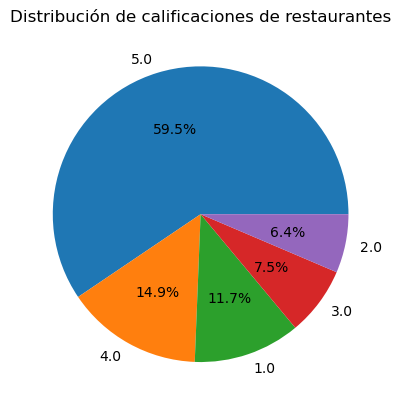

In [17]:
import matplotlib.pyplot as plt

plt.pie(x = data.stars.value_counts(), labels=data.stars.value_counts().index, autopct='%1.1f%%')
plt.title('Distribución de calificaciones de restaurantes')
plt.show()

In [29]:
user_restaurant = data.pivot_table(index='name', columns='user_id', values='stars', fill_value=0)
user_restaurant.head()

user_id,---zemaUC8WeJeWKqS6p9Q,--2F5G5LKt3h2cAXJbZptg,--7XOV5T9yZR5w1DIy_Dog,--8YG4BoOWFGjdh9Fxop-w,--_QWYpJ2In2IgW_bouSuQ,--kinfHwmtdjz03g8B8z8Q,-0-Cbo-4YzKmoJXpnckwbg,-0-TtVhV4PIUoDpUCOC0uQ,-06H6BQ5cS5A5Jpd_iiwCA,-09MjuD1Q0KwSYwdYbAzMw,...,zyP0-AxYAb61wVroBgR0ng,zyQcIz_DR9CM-Tah3B7Tfw,zyWX5BNC9JhEsrrzaK-X9g,zyakHeX-9wVqU33jn6NMtA,zym3VpXHS4YWRMXUJ-MxsQ,zyvAj-SNHqHnrTN0X5_adA,zyzSePGcKiiA15e1takl4g,zzkJpm2B4PNPHnXg-CMyog,zzudZ50i88aStmQ6Ft1cVA,zzzGgfvrSJ4AQeKtcgocIw
name,,,,,,,,,,,,,,,,,,,,,
101 Deli,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1114 Sports Bar & Games,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Eggs & Pizza,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Slice of Woodstock's,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AH Juice Organics,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Como tenemos tantas caracteristicas se debe reducir la dimensionalidad ya que si no se hace va a ser computacionalmente muy pesado  

Tenemos dos opciones PCA o SVD

SVD: Reduce caracteristicas por medio de la identificación de vectores propios manteniendo la máxima varianza  

Toma una matríz existente A y busca que sea cercana a los vectores ortogonales que definen las diferentes combinaciones de las filas de A * Sigma: vectores de la matríz ordenados por la varianza * Vtrans: Vectores ortogonales de las combianciones de las columnas   

A = U * Sigma * V trans  

k: cantidad de cols finales manteniendo comportamiendo de varianza  


In [30]:
from sklearn.decomposition import TruncatedSVD
SVD = TruncatedSVD(n_components= 659, random_state=42)
SVD.fit(user_restaurant)

TruncatedSVD(n_components=659, random_state=42)

In [31]:
num_sv = 7
print('La cantidad de informacion explicada con los primeros %d vectores singulares es de: ' % num_sv)
print('%.2f%%' % (100 * (1 - (SVD.singular_values_[0:num_sv].sum() / SVD.singular_values_.sum()))))

La cantidad de informacion explicada con los primeros 7 vectores singulares es de: 
95.83%


In [32]:
num_sv = 5
print('La cantidad de informacion explicada con los primeros %d vectores singulares es de: ' % num_sv)
print('%.2f%%' % (100 * (1 - (SVD.singular_values_[0:num_sv].sum() / SVD.singular_values_.sum()))))

La cantidad de informacion explicada con los primeros 5 vectores singulares es de: 
96.87%


In [23]:
num_sv = 10
print('La cantidad de informacion explicada con los primeros %d vectores singulares es de: ' % num_sv)
print('%.2f%%' % (100 * (1 - (SVD.singular_values_[0:num_sv].sum() / SVD.singular_values_.sum()))))

La cantidad de informacion explicada con los primeros 10 vectores singulares es de: 
94.35%


In [33]:
SVD_5 = TruncatedSVD(n_components= 5, random_state=42)
result_matrix = SVD_5.fit_transform(user_restaurant)
result_matrix

array([[ 0.08325865,  0.0827159 ,  0.15625382,  0.03734063, -0.03711163],
       [ 2.22545948,  1.18559033,  0.81729322,  2.08507674, -0.9080326 ],
       [ 1.65760476,  0.62004894,  0.43417323,  1.29517647, -0.26026814],
       ...,
       [ 0.09117129,  0.02401858,  0.03505825,  0.06723986, -0.02856405],
       [ 1.88249287,  1.20883569,  1.13118453,  0.92939539, -0.46709159],
       [ 0.2850191 ,  0.08991918, -0.01642041,  0.06385593, -0.06107389]],
      shape=(659, 5))

In [34]:
result_matrix.shape

(659, 5)

In [70]:
# calcular la correlacion y la distancia de coseno

from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity

corrMtx = np.corrcoef(result_matrix) # matriz de correlacion de Pearson
cosinemMtx = cosine_similarity(result_matrix) # matriz de similitud del coseno
corrSpMtx, pval =spearmanr(result_matrix.T)  # matriz de correlacion de Spearman

In [71]:
# transpuesta de sp
corrSpMtx[0:5]

array([[1. , 0.3, 0.3, ..., 0.5, 0.7, 0.4],
       [0.3, 1. , 1. , ..., 0.9, 0.7, 0.9],
       [0.3, 1. , 1. , ..., 0.9, 0.7, 0.9],
       [0.7, 0.2, 0.2, ..., 0.1, 0.7, 0.5],
       [0.3, 0.8, 0.8, ..., 0.9, 0.3, 0.5]], shape=(5, 659))

In [48]:
corrSpMtx

,0,1,2,3,4
0,1.000000,0.901063,0.865499,0.891074,-0.567292
1,0.901063,1.000000,0.842940,0.859276,-0.516187
2,0.865499,0.842940,1.000000,0.844158,-0.492782
3,0.891074,0.859276,0.844158,1.000000,-0.557754
4,-0.567292,-0.516187,-0.492782,-0.557754,1.000000


In [36]:
corrMtx[0:5, 0:5]

array([[1.        , 0.48612014, 0.34456424, 0.86775303, 0.64899054],
       [0.48612014, 1.        , 0.96755048, 0.7913078 , 0.97006447],
       [0.34456424, 0.96755048, 1.        , 0.65070888, 0.89952492],
       [0.86775303, 0.7913078 , 0.65070888, 1.        , 0.86323812],
       [0.64899054, 0.97006447, 0.89952492, 0.86323812, 1.        ]])

In [88]:
liked = 'Taco Bell'
names = user_restaurant.T.columns
name_list = list(names)
id_liked = name_list.index(liked)
corr_recom = corrMtx[id_liked]
corr_recom[0:10]

array([0.2174252 , 0.60299846, 0.73710169, 0.39440022, 0.48431101,
       0.48959878, 0.38728345, 0.32087249, 0.55873588, 0.67532528])

In [38]:
corr_recom[id_liked]

np.float64(1.0)

In [39]:
print('Recomendaaciones: ')
list(names[(corr_recom > 0.95) & (corr_recom < 0.99)])

Recomendaaciones: 


['Bristol Farms - Santa Barbara',
 'Del Valle Grill',
 'El Rincon Bohemio',
 'Freebirds',
 'Fresco Cafe',
 'Gladden and Sons Produce',
 'Habit Burger Grill',
 "Jeannine's Bakery & Restaurant",
 "Norton's Pastrami & Deli",
 'Panaderia Veronica',
 'Pressed',
 'Revolver',
 'Starbucks',
 'Subway',
 'Taqueria El Bajio',
 'The Daily Grind',
 'The Spot',
 "Wendy's",
 'Zookers Cafe']

In [89]:
ids = (corr_recom > 0.95) & (corr_recom < 0.99)
tmp = list()
for i in range (len(names[ids])):
    tmp.append((corr_recom[ids][i], names[ids][i]))
sorted(tmp, key=lambda x: x[0], reverse=True)

[(np.float64(0.9810166772724505), 'The Spot'),
 (np.float64(0.9804296607202788), 'El Rincon Bohemio'),
 (np.float64(0.9803579700132), 'Taqueria El Bajio'),
 (np.float64(0.970944443045394), 'Gladden and Sons Produce'),
 (np.float64(0.9684308958870503), 'The Daily Grind'),
 (np.float64(0.9658292385491927), 'Pressed'),
 (np.float64(0.9652135092893918), 'Fresco Cafe'),
 (np.float64(0.9638076056145822), 'Revolver'),
 (np.float64(0.9619481721566325), "Norton's Pastrami & Deli"),
 (np.float64(0.9590613859996042), 'Freebirds'),
 (np.float64(0.9588960452271392), 'Subway'),
 (np.float64(0.958300434495658), 'Zookers Cafe'),
 (np.float64(0.9576559742148897), "Jeannine's Bakery & Restaurant"),
 (np.float64(0.9573652106288166), 'Del Valle Grill'),
 (np.float64(0.9566537006813595), 'Panaderia Veronica'),
 (np.float64(0.9562925605387169), 'Bristol Farms - Santa Barbara'),
 (np.float64(0.9560523694457645), 'Habit Burger Grill'),
 (np.float64(0.9528886415061654), 'Starbucks'),
 (np.float64(0.95203390080

#### Con correlación de spearman 

In [ ]:
# el mismo proceso pero con Spearman

liked = 'Taco Bell'
names = user_restaurant.T.columns
name_list = list(names)
id_liked = name_list.index(liked)
corr_recomSP = corrSpMtx[id_liked]
corr_recomSP[0:10]

array([0.4, 0.9, 0.9, 0.5, 0.5, 0.6, 0.7, 0.7, 0.7, 0.9])

In [73]:
corr_recomSP[id_liked]

np.float64(0.9999999999999999)

In [85]:
ids = (corr_recomSP >= 0.9) & (corr_recomSP < 1)
tmpSP = list()
for i in range (len(names[ids])):
    tmpSP.append((corr_recomSP[ids][i], names[ids][i]))
sorted(tmpSP, key=lambda x: x[0], reverse=True)

[(np.float64(0.9999999999999999), 'Angel Oak'),
 (np.float64(0.9999999999999999), 'Backyard Bowls'),
 (np.float64(0.9999999999999999), 'Blue Corn Tacos Catering'),
 (np.float64(0.9999999999999999), 'Breakwater Restaurant'),
 (np.float64(0.9999999999999999), "Cantwell's Market & Deli"),
 (np.float64(0.9999999999999999), 'Ca’Dario - Montecito'),
 (np.float64(0.9999999999999999), 'China Palace'),
 (np.float64(0.9999999999999999), "Cody's Cafe"),
 (np.float64(0.9999999999999999), 'Corazon Cocina'),
 (np.float64(0.9999999999999999), 'Crush Bar and Tap'),
 (np.float64(0.9999999999999999), 'Daily Greenz'),
 (np.float64(0.9999999999999999), 'Dank Bowl Kitchen'),
 (np.float64(0.9999999999999999), "Dargan's Irish Pub & Restaurant"),
 (np.float64(0.9999999999999999), 'Del Pueblo Cafe'),
 (np.float64(0.9999999999999999), "Derf's Cafe"),
 (np.float64(0.9999999999999999), 'Dutch Garden Restaurant'),
 (np.float64(0.9999999999999999), 'El Pastorcito'),
 (np.float64(0.9999999999999999), "Esau's Cafe"),

In [86]:
len(tmpSP)

63

#### Con Coseno

In [76]:
cosinemMtx[ 0:5]

array([[1.00000000e+00, 7.39349672e-01, 6.91866360e-01, ...,
        7.40295299e-01, 8.83862523e-01, 5.26470445e-01],
       [7.39349672e-01, 1.00000000e+00, 9.81530178e-01, ...,
        9.81496032e-01, 9.39832216e-01, 8.40446841e-01],
       [6.91866360e-01, 9.81530178e-01, 1.00000000e+00, ...,
        9.85529980e-01, 9.30846368e-01, 8.82188403e-01],
       [6.59939164e-23, 5.88118719e-23, 1.63257401e-23, ...,
        4.95210834e-23, 5.15894441e-23, 5.44067655e-23],
       [8.14126313e-01, 9.83227870e-01, 9.43752039e-01, ...,
        9.69051156e-01, 9.37960670e-01, 7.64840667e-01]], shape=(5, 659))

In [77]:
# el mismo proceso pero con Spearman

liked = 'Taco Bell'
names = user_restaurant.T.columns
name_list = list(names)
id_liked = name_list.index(liked)
cos_rec = cosinemMtx[id_liked]
cos_rec[0:10]

array([ 6.96221600e-01,  8.16545863e-01,  8.90008206e-01, -6.34431473e-23,
        7.57404006e-01,  3.25404986e-01,  7.91697032e-01,  6.31191628e-01,
        8.07259892e-01,  7.69999145e-01])

In [82]:
ids = (cos_rec >= 0.95) & (cos_rec < 0.99)
tmpCos= list()
for i in range (len(names[ids])):
    tmpCos.append((cos_rec[ids][i], names[ids][i]))
sorted(tmpCos, key=lambda x: x[0], reverse=True)


[(np.float64(0.9896674166203621), 'Habit Burger Grill'),
 (np.float64(0.9893193623964881), 'Subway'),
 (np.float64(0.9887885405304342), 'El Rincon Bohemio'),
 (np.float64(0.9885362266523458), 'The Spot'),
 (np.float64(0.9831007569392578), "Z's - Taphouse & Grill"),
 (np.float64(0.9827165290445461), 'Revolver'),
 (np.float64(0.9822383074277905), "Bree'osh"),
 (np.float64(0.9778528259650718), 'Ca’Dario - Montecito'),
 (np.float64(0.9777154257338201), 'Sushi GoGo'),
 (np.float64(0.9760836078140227), "Rusty's Pizza Parlor"),
 (np.float64(0.9758962776463664), "Mulligan's Cafe & Bar"),
 (np.float64(0.9751119635105776), 'Kanaloa Seafood'),
 (np.float64(0.9727829884667968), "Wendy's"),
 (np.float64(0.9711802999381679), 'Hibachi Steak House & Sushi Bar'),
 (np.float64(0.9710902302744389), 'Corazon Cocina'),
 (np.float64(0.9707856908528327), 'Finch & Fork'),
 (np.float64(0.9701793885058727), "Super Cuca's Taqueria"),
 (np.float64(0.9695797609097918), 'The Drunken Crab'),
 (np.float64(0.967956328

In [81]:
print(len(tmp))

46


In [90]:
# comparacion de los tres metodos
print("Coseno:", len(tmpCos))
print("Pearson:", len(tmp))
print("Spearman:", len(tmpSP))

# comparación de las recomendaciones que dió cada método 


Coseno: 46
Pearson: 19
Spearman: 63


In [94]:
set_cos   = {name for _, name in tmpCos}
set_pear  = {name for _, name in tmp}
set_spear = {name for _, name in tmpSP}

def overlap(a,b):
    inter = a & b
    union = a | b
    return {'intersection_count': len(inter),
            'jaccard': len(inter)/len(union) if union else 0,
            'overlap_pct_of_a': len(inter)/len(a) if a else 0}

print('Intersecciones:')
print('Pearson vs Coseno:', overlap(set_pear, set_cos))
print('Pearson vs Spearman:', overlap(set_pear, set_spear))
print('Coseno vs Spearman:', overlap(set_cos, set_spear))

Intersecciones:
Pearson vs Coseno: {'intersection_count': 8, 'jaccard': 0.14035087719298245, 'overlap_pct_of_a': 0.42105263157894735}
Pearson vs Spearman: {'intersection_count': 5, 'jaccard': 0.06493506493506493, 'overlap_pct_of_a': 0.2631578947368421}
Coseno vs Spearman: {'intersection_count': 9, 'jaccard': 0.09, 'overlap_pct_of_a': 0.1956521739130435}


In [95]:
# intersecciones
inter_pear_cos   = set_pear & set_cos
inter_pear_spear = set_pear & set_spear
inter_cos_spear  = set_cos & set_spear
inter_all        = set_pear & set_cos & set_spear

print(f'Pearson ∩ Coseno (count): {len(inter_pear_cos)}')
print(sorted(inter_pear_cos))

print(f'Pearson ∩ Spearman (count): {len(inter_pear_spear)}')
print(sorted(inter_pear_spear))

print(f'Coseno ∩ Spearman (count): {len(inter_cos_spear)}')
print(sorted(inter_cos_spear))

print(f'Triple intersección (count): {len(inter_all)}')
print(sorted(inter_all))

Pearson ∩ Coseno (count): 8
['Del Valle Grill', 'El Rincon Bohemio', 'Habit Burger Grill', 'Revolver', 'Subway', 'Taqueria El Bajio', 'The Spot', "Wendy's"]
Pearson ∩ Spearman (count): 5
['Freebirds', "Norton's Pastrami & Deli", 'Revolver', 'Taqueria El Bajio', 'Zookers Cafe']
Coseno ∩ Spearman (count): 9
['Ca’Dario - Montecito', "Cody's Cafe", 'Corazon Cocina', 'Kanaloa Seafood', 'Lighthouse Coffee', 'Night Lizard Brewing Company', 'Revolver', 'Taqueria El Bajio', 'The Palace Grill']
Triple intersección (count): 2
['Revolver', 'Taqueria El Bajio']
